In [ ]:
from huggingface_hub import login
import pandas as pd

login(token="hf_token")s
splits = {'vinmec_article_subtitle': 'data/vinmec_article_subtitle-00000-of-00001-e98cf5ea3053f42f.parquet', 'medical_qa': 'data/medical_qa-00000-of-00001-5ff72792fc000f50.parquet', 'full': 'data/full-00000-of-00001-5cf852564dfb41df.parquet', 'vinmec_article_content': 'data/vinmec_article_content-00000-of-00001-d24ac05490384885.parquet', 'vinmec_article_main': 'data/vinmec_article_main-00000-of-00001-fb76eca8bdfcf377.parquet'}
base_url = "hf://datasets/urnus11/Vietnamese-Healthcare/"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [ ]:
# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
print("📥 Đang tải tất cả các phần của dataset...\n")
datasets = {}

for name, path in splits.items():
    datasets[name] = pd.read_parquet(base_url + path)

print(f"\n🎉 Hoàn thành! Đã tải {len(datasets)} phần của dataset")

📥 Đang tải tất cả các phần của dataset...

✅ vinmec_article_subtitle: 163,186 mẫu
✅ medical_qa: 10,015 mẫu
✅ full: 173,201 mẫu
✅ vinmec_article_content: 32,604 mẫu
✅ vinmec_article_main: 138,525 mẫu

🎉 Hoàn thành! Đã tải 5 phần của dataset


In [ ]:
print("="*80)
print("📊 TỔNG QUAN CÁC PHẦN CỦA DATASET")
print("="*80)

summary_data = []
for name, df in datasets.items():
    summary_data.append({
        'Tên Dataset': name,
        'Số mẫu': f"{len(df):,}",
        'Số cột': len(df.columns),
        'Tên các cột': ', '.join(df.columns.tolist()),
        'Dung lượng (MB)': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

📊 TỔNG QUAN CÁC PHẦN CỦA DATASET


,Tên Dataset,Số mẫu,Số cột,Tên các cột,Dung lượng (MB)
0,vinmec_article_subtitle,"163,186",3,"url, title, content",405.21
1,medical_qa,"10,015",3,"title, content, url",14.50
2,full,"173,201",3,"url, title, content",419.71
3,vinmec_article_content,"32,604",3,"title, content, url",374.09
4,vinmec_article_main,"138,525",3,"url, title, content",385.37


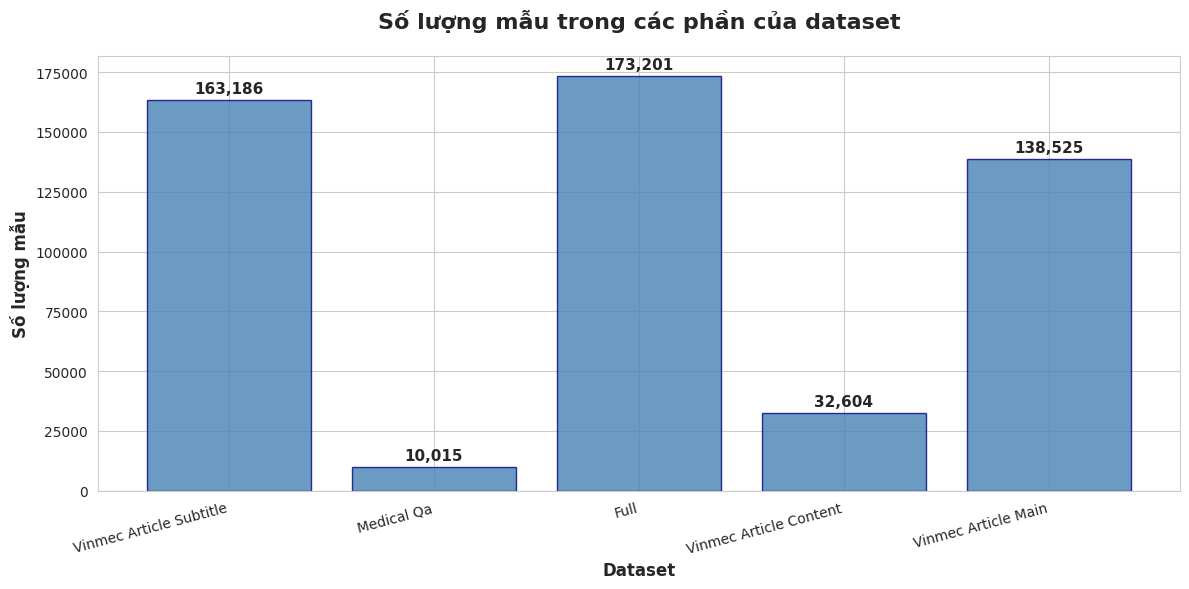

In [ ]:
plt.figure(figsize=(12, 6))
names = [name.replace('_', ' ').title() for name in datasets.keys()]
counts = [len(df) for df in datasets.values()]

bars = plt.bar(range(len(names)), counts, color='steelblue', edgecolor='navy', alpha=0.8)
plt.title('Số lượng mẫu trong các phần của dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Dataset', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng mẫu', fontsize=12, fontweight='bold')
plt.xticks(range(len(names)), names, rotation=15, ha='right')

# Thêm giá trị lên đầu cột
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Khám phá 'full' (vinmec_article_subtitle + medical_qa)

In [ ]:
df_full = datasets['full']

print("="*80)
print("KHÁM PHÁ FULL DATASET")

print(f"\n📏 Kích thước: {df_full.shape[0]:,} hàng × {df_full.shape[1]} cột")
print(f"\n📋 Các cột: {df_full.columns.tolist()}")

print("\nKiểm tra giá trị null:")
null_info = df_full.isnull().sum().to_frame('Số null')
null_info['% Null'] = (null_info['Số null'] / len(df_full) * 100).round(2)
display(null_info)

print("\n5 mẫu ngẫu nhiên:")
display(df_full.sample(5))

print("\nThống kê tổng quan:")
display(df_full.describe(include='all'))

KHÁM PHÁ FULL DATASET

📏 Kích thước: 173,201 hàng × 3 cột

📋 Các cột: ['url', 'title', 'content']

Kiểm tra giá trị null:


,Số null,% Null
url,0,0.0
title,0,0.0
content,0,0.0



5 mẫu ngẫu nhiên:


,url,title,content
162861,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/san-phu-khoa-va-ho-tro-sinh-san/co-nen-quan...,Có được quan hệ sau khi tiêm vaccine covid? Tiêm vaccine covid sau bao lâu được quan hệ?,1. Có được quan hệ sau khi tiêm vaccine covid? Tiêm vaccine covid sau bao lâu được quan hệ?\nSau...
135738,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/cac-con-mat-y-thuc-thoan...,Động kinh vắng ý thức,1. Động kinh vắng ý thức\nĐộng kinh vắng ý thức là tình trạng xuất hiện cơn động kinh nhưng chỉ ...
172023,https://www.vinmec.com/vi/suc-khoe-tong-quat/tu-van-bac-si/bi-danh-vao-vung-thai-duong-da-3-nam-...,Bị đánh vào vùng thái dương đã 3 năm liệu có tổn thương gì không?,Bạn cần đi khám để chụp cộng hưởng từ sọ não (MRI) để đánh giá tổn thương có hay không nhé.
115500,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/san-phu-khoa-va-ho-tro-sinh-san/kiem-tra-7-...,7 cách giúp tinh trùng khỏe mạnh,2. 7 cách giúp tinh trùng khỏe mạnh\n2.4. Hãy cân trước khi bạn uống rượu hoặc thức uống chứa ca...
143984,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/dinh-duong/vai-tro-cua-protein-doi-voi-su-h...,Rủi ro khi ăn quá nhiều protein,4. Rủi ro khi ăn quá nhiều protein\n4.1. Các tác dụng phụ Nghiên cứu y học cho thấy tiêu thụ quá...



Thống kê tổng quan:


,url,title,content
count,173201,173201,173201
unique,38630,138899,172942
top,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/cac-dau-sinh-hoc-cua-nhi...,Tương tác thuốc,Hiện nay vaccine phòng Covid-19 của Pfizer và Modena của Mỹ chưa được nhập về Việt Nam và cũng c...
freq,41,1591,7


📊 PHÂN TÍCH ĐỘ DÀI VĂN BẢN - FULL DATASET

📝 Cột 'url':
   - Độ dài TB: 103 ký tự
   - Trung vị: 99 ký tự
   - Min: 65 | Max: 246 ký tự
   - Số từ TB: 1 từ

📝 Cột 'title':
   - Độ dài TB: 40 ký tự
   - Trung vị: 36 ký tự
   - Min: 0 | Max: 1521 ký tự
   - Số từ TB: 9 từ

📝 Cột 'content':
   - Độ dài TB: 1068 ký tự
   - Trung vị: 841 ký tự
   - Min: 18 | Max: 23998 ký tự
   - Số từ TB: 233 từ


/tmp/ipykernel_37/3706487397.py:76: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


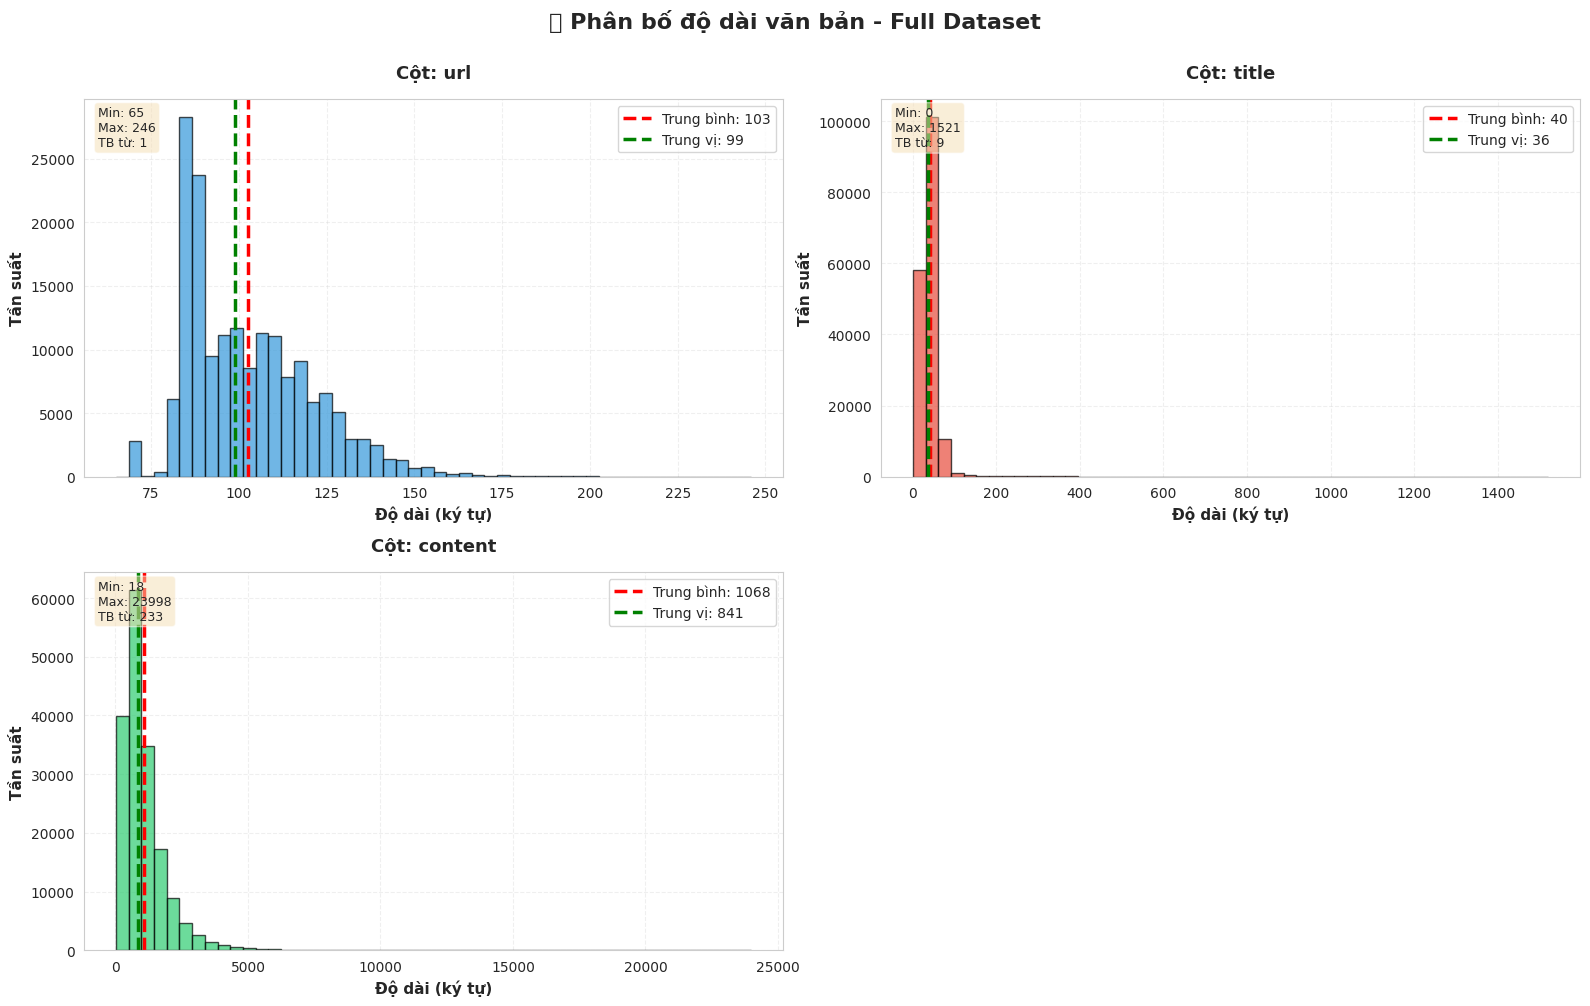

In [ ]:
print("="*80)
print("📊 PHÂN TÍCH ĐỘ DÀI VĂN BẢN - FULL DATASET")
print("="*80)

# Tính độ dài cho tất cả các cột
lengths_data = {}
for col in df_full.columns:
    if df_full[col].dtype == 'object':
        lengths = df_full[col].astype(str).str.len()
        words = df_full[col].astype(str).str.split().str.len()

        lengths_data[col] = {
            'lengths': lengths,
            'words': words,
            'mean_chars': lengths.mean(),
            'median_chars': lengths.median(),
            'max_chars': lengths.max(),
            'min_chars': lengths.min(),
            'mean_words': words.mean()
        }

        print(f"\n📝 Cột '{col}':")
        print(f"   - Độ dài TB: {lengths.mean():.0f} ký tự")
        print(f"   - Trung vị: {lengths.median():.0f} ký tự")
        print(f"   - Min: {lengths.min()} | Max: {lengths.max()} ký tự")
        print(f"   - Số từ TB: {words.mean():.0f} từ")

# Vẽ biểu đồ
n_cols_data = len(lengths_data)
if n_cols_data > 0:
    n_rows = (n_cols_data + 1) // 2
    n_cols = min(2, n_cols_data)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
    if n_cols_data == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

    for idx, (col_name, data) in enumerate(lengths_data.items()):
        ax = axes[idx]

        # Histogram
        n, bins, patches = ax.hist(data['lengths'], bins=50,
                                    color=colors[idx % len(colors)],
                                    edgecolor='black', alpha=0.7)

        # Đường trung bình
        ax.axvline(data['mean_chars'], color='red', linestyle='--', linewidth=2.5,
                   label=f"Trung bình: {data['mean_chars']:.0f}")

        # Đường trung vị
        ax.axvline(data['median_chars'], color='green', linestyle='--', linewidth=2.5,
                   label=f"Trung vị: {data['median_chars']:.0f}")

        ax.set_title(f"Cột: {col_name}", fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel('Độ dài (ký tự)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Tần suất', fontsize=11, fontweight='bold')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3, linestyle='--')

        # Thêm text box với thống kê
        textstr = f'Min: {data["min_chars"]}\nMax: {data["max_chars"]}\nTB từ: {data["mean_words"]:.0f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)

    # Ẩn subplot thừa
    for idx in range(len(lengths_data), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Phân bố độ dài văn bản - Full Dataset',
                 fontsize=16, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.show()

### Khám phá 'medical_qa'

In [ ]:
df_qa = datasets['medical_qa']

print("="*80)
print("🔍 KHÁM PHÁ CHI TIẾT: MEDICAL Q&A")
print("="*80)

print(f"\n📏 Kích thước: {df_qa.shape[0]:,} hàng × {df_qa.shape[1]} cột")
print(f"\n📋 Tên các cột: {df_qa.columns.tolist()}")

print("\n📊 Thông tin kiểu dữ liệu:")
display(df_qa.dtypes.to_frame('Kiểu dữ liệu'))

print("\n❓ Kiểm tra giá trị null:")
null_info = df_qa.isnull().sum().to_frame('Số null')
null_info['% Null'] = (null_info['Số null'] / len(df_qa) * 100).round(2)
display(null_info)

print("\n👀 5 mẫu đầu tiên:")
display(df_qa.head())

print("\n📊 Thống kê mô tả:")
display(df_qa.describe(include='all'))


🔍 KHÁM PHÁ CHI TIẾT: MEDICAL Q&A

📏 Kích thước: 10,015 hàng × 3 cột

📋 Tên các cột: ['title', 'content', 'url']

📊 Thông tin kiểu dữ liệu:


,Kiểu dữ liệu
title,object
content,object
url,object



❓ Kiểm tra giá trị null:


,Số null,% Null
title,0,0.0
content,0,0.0
url,0,0.0



👀 5 mẫu đầu tiên:


,title,content,url
0,Đang chích ngừa viêm gan B có chích ngừa Covid-19 được không?,"Nếu anh/chị đang tiêm ngừa vaccine phòng bệnh viêm gan B, anh/chị vẫn có thể tiêm phòng vaccine ...",https://vnexpress.net/tu-van-tiem-vaccine-covid-19-an-toan-hieu-qua-p57
1,"Đau đầu, căng thẳng do công việc, suy giảm trí nhớ khoảng gần một năm phải làm sao?","Tình trạng đau đầu theo bạn mô tả thì chưa rõ. Vì thế, bác sĩ khuyến khích bạn đến cơ sở y tế ho...",https://www.vinmec.com/vi/suc-khoe-tong-quat/tu-van-bac-si/dau-dau-cang-thang-do-cong-viec-suy-g...
2,Đặt lưu lượng khí hệ thống Jackson-Rees thấp hơn quy định khi sử dụng gây mê cho trẻ em sẽ gây h...,Hệ thống Jackson – Rees dùng khi gây mê để tránh hít lại khí thở ra cần đặt lưu lượng khí mới gấ...,https://www.vinmec.com/vi/suc-khoe-tong-quat/tu-van-bac-si/dat-luu-luong-khi-he-thong-jackson-re...
3,Bé 13 tháng tuổi uống thuốc Acyclovir có được không?,"Acyclovir có thể sử dụng cho cả trẻ dưới 13 tháng nếu có chỉ định. Tuy nhiên, Acyclovir là thuốc...",https://www.vinmec.com/vi/suc-khoe-tong-quat/tu-van-bac-si/be-13-thang-tuoi-uong-thuoc-acyclovir...
4,Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ...,Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu tiên tiêm trước...,https://vnexpress.net/tu-van-tiem-vaccine-covid-19-an-toan-hieu-qua-p21



📊 Thống kê mô tả:


,title,content,url
count,10015,10015,10015
unique,9990,9896,7365
top,gia đình tôi muốn đăng ký tiêm vaccine Covid-19 thì làm sao?,Hiện nay vaccine phòng Covid-19 của Pfizer và Modena của Mỹ chưa được nhập về Việt Nam và cũng c...,https://vnexpress.net/tu-van-tiem-vaccine-covid-19-an-toan-hieu-qua-p57
freq,2,7,18


📝 PHÂN TÍCH ĐỘ DÀI VĂN BẢN - MEDICAL Q&A

📊 Thống kê độ dài văn bản:

🔹 Cột: title
   - Độ dài trung bình: 104 ký tự
   - Số từ trung bình: 23 từ
   - Min: 17 ký tự | Max: 1521 ký tự

🔹 Cột: content
   - Độ dài trung bình: 495 ký tự
   - Số từ trung bình: 110 từ
   - Min: 33 ký tự | Max: 7526 ký tự

🔹 Cột: url
   - Độ dài trung bình: 99 ký tự
   - Số từ trung bình: 1 từ
   - Min: 66 ký tự | Max: 211 ký tự



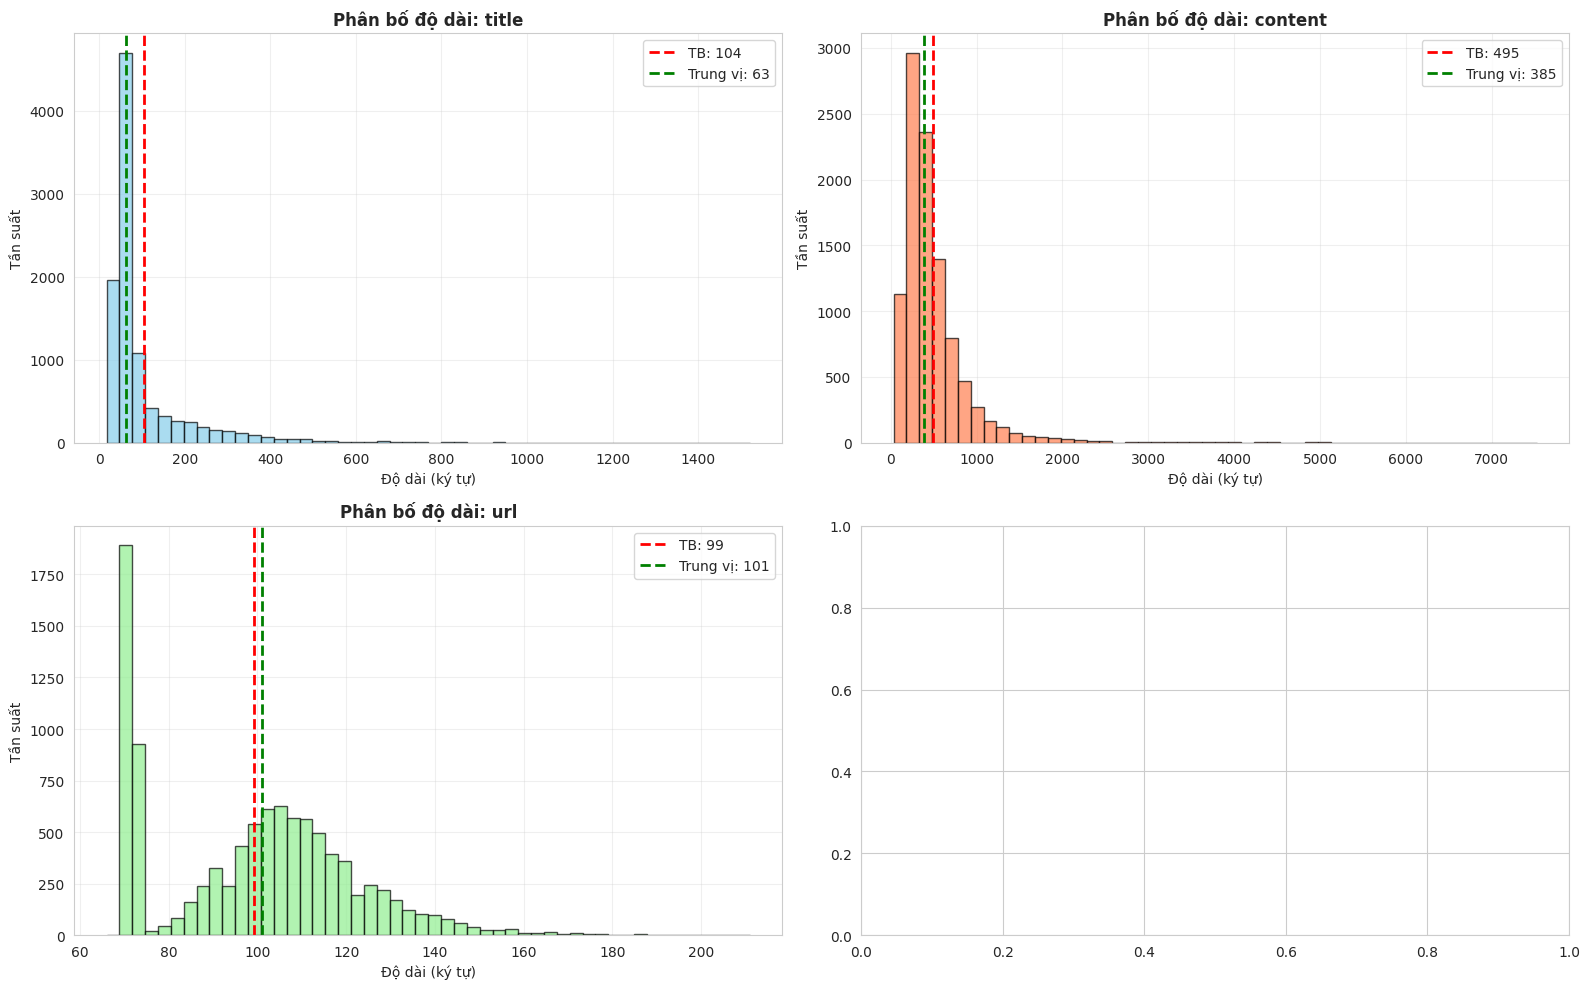

In [ ]:
print("="*80)
print("📝 PHÂN TÍCH ĐỘ DÀI VĂN BẢN - MEDICAL Q&A")
print("="*80)

# Tính toán độ dài
for col in df_qa.columns:
    df_qa[f'{col}_length'] = df_qa[col].astype(str).str.len()
    df_qa[f'{col}_words'] = df_qa[col].astype(str).str.split().str.len()

# Hiển thị thống kê
print("\n📊 Thống kê độ dài văn bản:\n")
for col in [c for c in df_qa.columns if not c.endswith('_length') and not c.endswith('_words')]:
    print(f"🔹 Cột: {col}")
    print(f"   - Độ dài trung bình: {df_qa[f'{col}_length'].mean():.0f} ký tự")
    print(f"   - Số từ trung bình: {df_qa[f'{col}_words'].mean():.0f} từ")
    print(f"   - Min: {df_qa[f'{col}_length'].min()} ký tự | Max: {df_qa[f'{col}_length'].max()} ký tự")
    print()

# Trực quan hóa
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['skyblue', 'coral', 'lightgreen', 'plum']

text_cols = [c for c in df_qa.columns if not c.endswith('_length') and not c.endswith('_words')]

for idx, col in enumerate(text_cols[:4]):
    if f'{col}_length' in df_qa.columns:
        row = idx // 2
        col_idx = idx % 2

        ax = axes[row, col_idx]
        lengths = df_qa[f'{col}_length']

        ax.hist(lengths, bins=50, color=colors[idx], edgecolor='black', alpha=0.7)
        ax.set_title(f'Phân bố độ dài: {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Độ dài (ký tự)', fontsize=10)
        ax.set_ylabel('Tần suất', fontsize=10)
        ax.axvline(lengths.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'TB: {lengths.mean():.0f}')
        ax.axvline(lengths.median(), color='green', linestyle='--', linewidth=2,
                   label=f'Trung vị: {lengths.median():.0f}')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Khám phá 'vinmec_article_subtitle'

In [ ]:
df_subtitle = datasets['vinmec_article_subtitle']

print("="*80)
print("🔍 KHÁM PHÁ CHI TIẾT: VINMEC ARTICLE SUBTITLE")
print("="*80)

print(f"\n📏 Kích thước: {df_subtitle.shape[0]:,} hàng × {df_subtitle.shape[1]} cột")
print(f"\n📋 Các cột: {df_subtitle.columns.tolist()}")

print("\n👀 5 mẫu đầu tiên:")
display(df_subtitle.head())

print("\n📊 Thống kê mô tả:")
display(df_subtitle.describe(include='all'))

# Phân tích độ dài
for col in df_subtitle.columns:
    if df_subtitle[col].dtype == 'object':
        lengths = df_subtitle[col].astype(str).str.len()
        words = df_subtitle[col].astype(str).str.split().str.len()

        print(f"\n📝 Cột '{col}':")
        print(f"   - Độ dài TB: {lengths.mean():.0f} ký tự (Min: {lengths.min()}, Max: {lengths.max()})")
        print(f"   - Số từ TB: {words.mean():.0f} từ")

🔍 KHÁM PHÁ CHI TIẾT: VINMEC ARTICLE SUBTITLE

📏 Kích thước: 163,186 hàng × 3 cột

📋 Các cột: ['url', 'title', 'content']

👀 5 mẫu đầu tiên:


,url,title,content
0,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/ky-thuat-mo-mang-phoi-to...,Mục đích của kỹ thuật mở màng phổi tối thiểu,1. Mục đích của kỹ thuật mở màng phổi tối thiểu\nPhục hồi lại áp lực âm trong khoang màng phổi g...
1,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/ky-thuat-mo-mang-phoi-to...,Chỉ định mở màng phổi khi nào?,2. Chỉ định mở màng phổi khi nào?\nMở màng phổi tối thiểu đặt ống thông vào lồng ngực có thể đượ...
2,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/ky-thuat-mo-mang-phoi-to...,Chống chỉ định mở màng phổi,"3. Chống chỉ định mở màng phổi\nKhông có chống chỉ định tuyệt đối cho mở màng phổi, ngoại trừ tr..."
3,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/ky-thuat-mo-mang-phoi-to...,Chuẩn bị thực hiện mở màng phổi,4. Chuẩn bị thực hiện mở màng phổi\n4.1 Người thực hiện thủ thuật 01 bác sĩ được đào tạo thành t...
4,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/ky-thuat-mo-mang-phoi-to...,Các bước tiến hành mở màng phổi,"5. Các bước tiến hành mở màng phổi\n5.1 Kiểm tra lại hồ sơ bệnh án Kiểm tra lại hồ sơ bệnh án, g..."



📊 Thống kê mô tả:


,url,title,content
count,163186,163186,163186
unique,31265,128921,163046
top,https://www.vinmec.com/vi/tin-tuc/thong-tin-suc-khoe/suc-khoe-tong-quat/cac-dau-sinh-hoc-cua-nhi...,Tương tác thuốc,1. Biểu hiện lâm sàng của viêm loét đại tràng chảy máu\nViêm loét đại tràng chảy máu đặc trưng b...
freq,41,1591,3



📝 Cột 'url':
   - Độ dài TB: 103 ký tự (Min: 65, Max: 246)
   - Số từ TB: 1 từ

📝 Cột 'title':
   - Độ dài TB: 36 ký tự (Min: 0, Max: 299)
   - Số từ TB: 8 từ

📝 Cột 'content':
   - Độ dài TB: 1104 ký tự (Min: 18, Max: 23998)
   - Số từ TB: 241 từ


📊 PHÂN TÍCH ĐỘ DÀI VĂN BẢN - VINMEC ARTICLE SUBTITLE

📝 Cột 'url':
   - Độ dài TB: 103 ký tự
   - Trung vị: 99 ký tự
   - Min: 65 | Max: 246 ký tự
   - Số từ TB: 1 từ

📝 Cột 'title':
   - Độ dài TB: 36 ký tự
   - Trung vị: 35 ký tự
   - Min: 0 | Max: 299 ký tự
   - Số từ TB: 8 từ

📝 Cột 'content':
   - Độ dài TB: 1104 ký tự
   - Trung vị: 877 ký tự
   - Min: 18 | Max: 23998 ký tự
   - Số từ TB: 241 từ


/tmp/ipykernel_37/2404357138.py:78: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


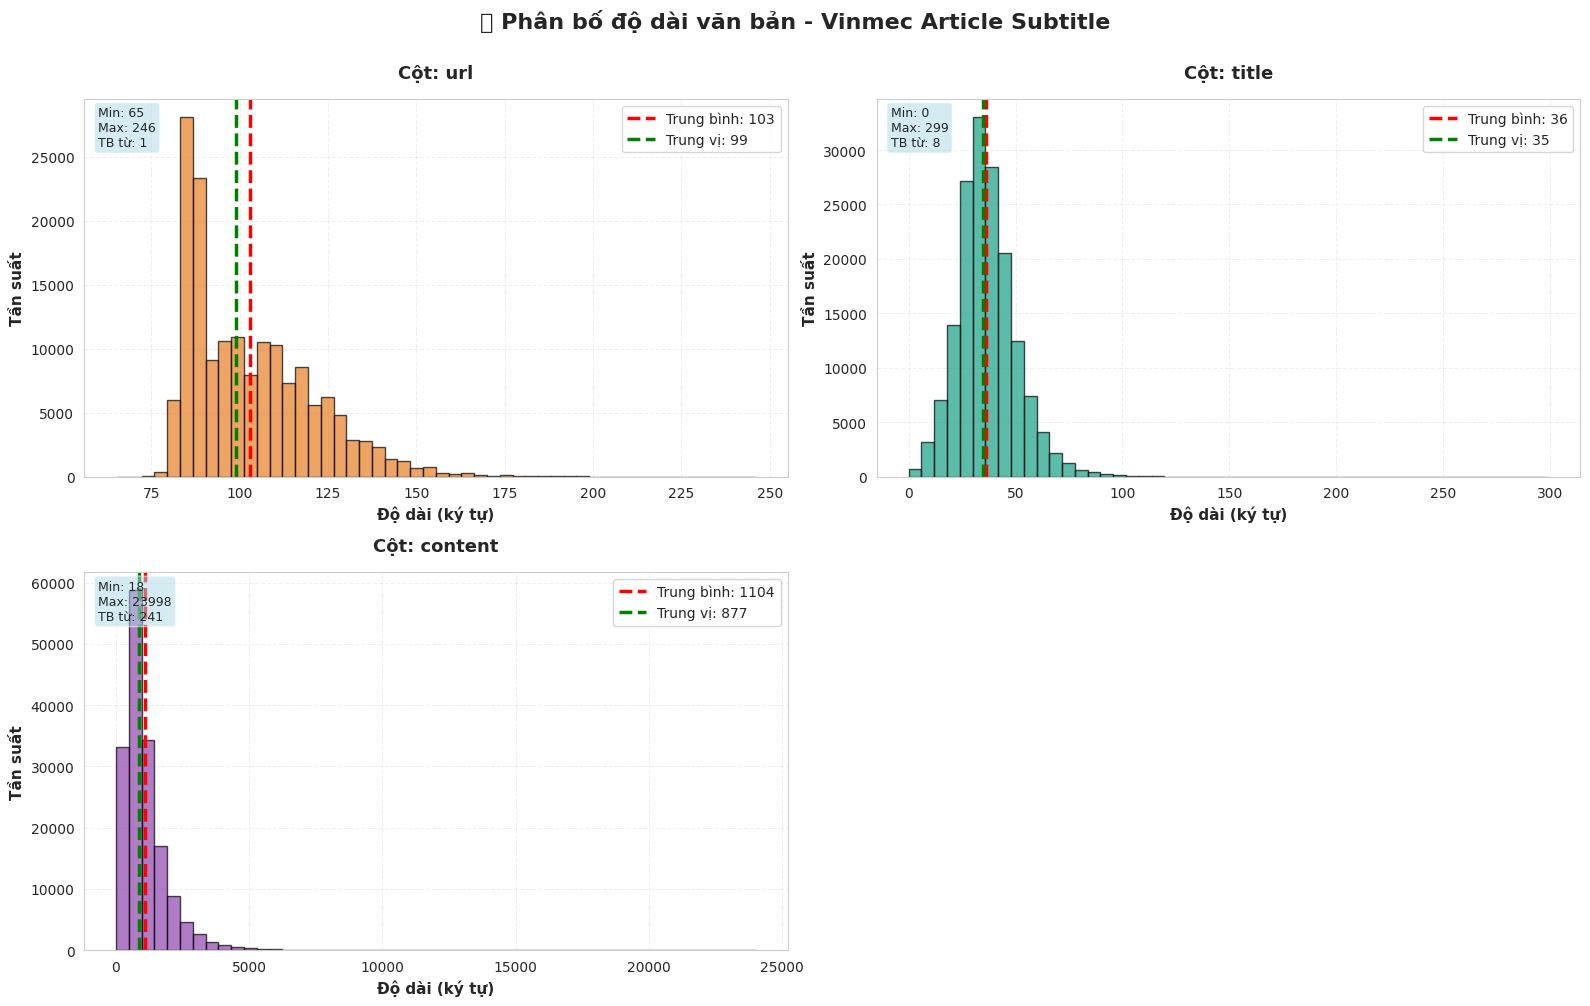

In [ ]:
df_subtitle = datasets['vinmec_article_subtitle']

print("="*80)
print("📊 PHÂN TÍCH ĐỘ DÀI VĂN BẢN - VINMEC ARTICLE SUBTITLE")
print("="*80)

# Tính độ dài cho tất cả các cột
lengths_data = {}
for col in df_subtitle.columns:
    if df_subtitle[col].dtype == 'object':
        lengths = df_subtitle[col].astype(str).str.len()
        words = df_subtitle[col].astype(str).str.split().str.len()

        lengths_data[col] = {
            'lengths': lengths,
            'words': words,
            'mean_chars': lengths.mean(),
            'median_chars': lengths.median(),
            'max_chars': lengths.max(),
            'min_chars': lengths.min(),
            'mean_words': words.mean()
        }

        print(f"\n📝 Cột '{col}':")
        print(f"   - Độ dài TB: {lengths.mean():.0f} ký tự")
        print(f"   - Trung vị: {lengths.median():.0f} ký tự")
        print(f"   - Min: {lengths.min()} | Max: {lengths.max()} ký tự")
        print(f"   - Số từ TB: {words.mean():.0f} từ")

# Vẽ biểu đồ
n_cols_data = len(lengths_data)
if n_cols_data > 0:
    n_rows = (n_cols_data + 1) // 2
    n_cols = min(2, n_cols_data)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
    if n_cols_data == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    colors = ['#e67e22', '#16a085', '#8e44ad', '#c0392b', '#27ae60']

    for idx, (col_name, data) in enumerate(lengths_data.items()):
        ax = axes[idx]

        # Histogram
        n, bins, patches = ax.hist(data['lengths'], bins=50,
                                    color=colors[idx % len(colors)],
                                    edgecolor='black', alpha=0.7)

        # Đường trung bình
        ax.axvline(data['mean_chars'], color='red', linestyle='--', linewidth=2.5,
                   label=f"Trung bình: {data['mean_chars']:.0f}")

        # Đường trung vị
        ax.axvline(data['median_chars'], color='green', linestyle='--', linewidth=2.5,
                   label=f"Trung vị: {data['median_chars']:.0f}")

        ax.set_title(f"Cột: {col_name}", fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel('Độ dài (ký tự)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Tần suất', fontsize=11, fontweight='bold')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3, linestyle='--')

        # Thêm text box với thống kê
        textstr = f'Min: {data["min_chars"]}\nMax: {data["max_chars"]}\nTB từ: {data["mean_words"]:.0f}'
        props = dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)

    # Ẩn subplot thừa
    for idx in range(len(lengths_data), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('📊 Phân bố độ dài văn bản - Vinmec Article Subtitle',
                 fontsize=16, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.show()